# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [1]:
# Установка необходимых библиотек
!pip install -q pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers
!pip install -q huggingface_hub
!pip install -q datasets==2.21.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 18.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

*Бизнес проблема сводится к задаче* дообучения LLM путем формирования специализированного мед датасета, для лучшей классификации

*Выбранные метрики:* F1-score и Accuracy

*Обоснование выбора (проблема Accuracy при дисбалансе):* использование метрика Accuracy может показывать хорошие результаты, при этом плохо распознавая редкие классы. Поэтому метрика F1-score будет более точной, так как она учитывает качество предсказаний класса в независимости от частоты его появления



## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).


The repository for blinoff/medical_qa_ru_data contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/blinoff/medical_qa_ru_data.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split: 0 examples [00:00, ? examples/s]

Размер: (190335, 6)

Колонки датасета:
['date', 'categ', 'theme', 'desc', 'ans', 'spec10']


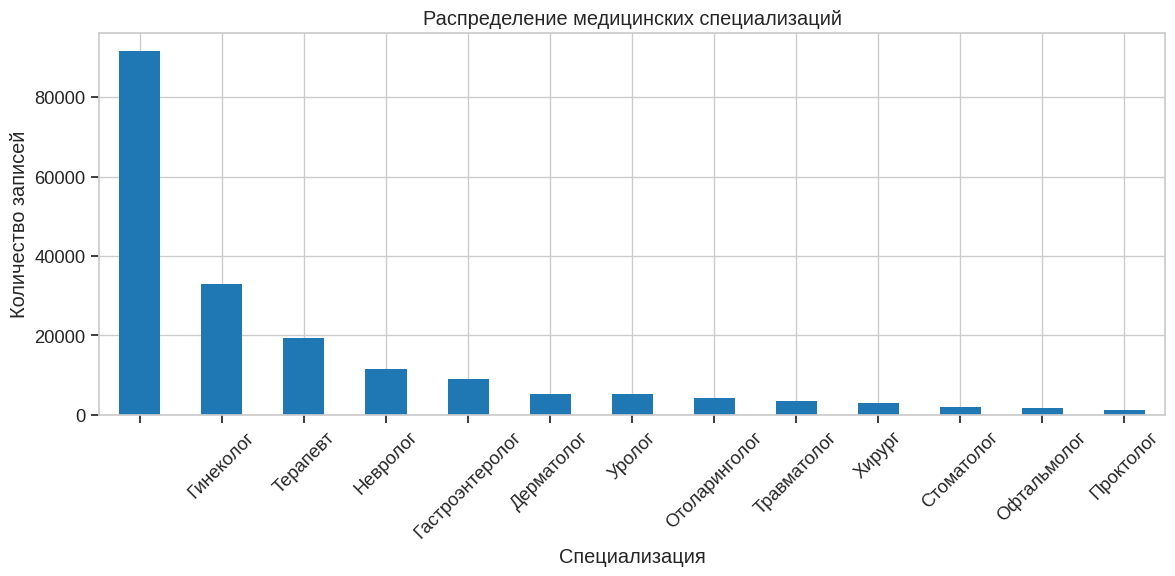


3 случайных примера:


,desc,spec10
795,Моему сыну 2.3 года он постоянно дерётся и не ...,
155677,Нужно сделать мрт коленного сустава. Ранее был...,
70170,"Здравствуйте. Подскажите, пожалуйста, на какой...",Гинеколог


In [3]:
# === ВАШ КОД ЗДЕСЬ ===

dataset = load_dataset("blinoff/medical_qa_ru_data")
df = dataset["train"].to_pandas()
print(f"Размер: {df.shape}")

print("\nКолонки датасета:")
print(df.columns.tolist())

plt.figure(figsize=(12, 6))
df["spec10"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Распределение медицинских специализаций")
plt.xlabel("Специализация")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n3 случайных примера:")
display(df[["desc", "spec10"]].sample(3, random_state=42))
# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


In [4]:
# === ВАШ КОД ЗДЕСЬ ===
initial_size = len(df)

df_clean = df.dropna(subset=["desc", "spec10"])
df_clean = df_clean[["desc", "spec10"]]

df_clean = df_clean[
    (df_clean["desc"].str.strip() != "") &
    (df_clean["spec10"].str.strip() != "")
]

df_clean = df_clean[
    (df_clean["desc"].str.len() >= 30) &
    (df_clean["desc"].str.len() <= 2000)
]
df_clean = df_clean.reset_index(drop=True)

final_size = len(df_clean)

print(f"Размер до очистки: {initial_size}")
print(f"Размер после очистки: {final_size}")
print(f"Разница: {initial_size - final_size}")
# === КОНЕЦ ВАШЕГО КОДА ===


Размер до очистки: 190335
Размер после очистки: 89319
Разница: 101016


## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


**Обоснование выбора энкодерной модели (пример):**

*Я выбрал модель BAAI/bge-m3, потому что* по бенчмарку ruMTEB (раздел STS) она демонстрирует высокие показатели качества. В сравнении с cointegrated/rubert-tiny2 она значительно точнее улавливает смысловые оттенки

**Обоснование порога косинусного сходства:**

*Я выбрал порог 0.95, так как...* он является золотым стандартом для семантической дедупликации, позволяя удалять полные парафразы и переформулировки вопросов.



In [5]:
!pip install -q rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.4 MB/s eta 0:00:00


In [6]:
# === Пример обоснования выбора модели ===
from rapidfuzz import fuzz
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
# 1. Точное совпадение
sample_df = df_clean.sample(n=10000, random_state=42).reset_index(drop=True)

exact_df = sample_df.drop_duplicates(subset="desc").reset_index(drop=True)
print("Удалено:", len(sample_df) - len(exact_df))
# 2. Нечеткое сходство (MinHash или Levenshtein)


texts = exact_df["desc"].tolist()
duplicates = set()
threshold = 95

for i in range(len(texts)):
    if i in duplicates:
        continue
    for j in range(i + 1, min(i + 50, len(texts))):
        score = fuzz.ratio(texts[i], texts[j])
        if score >= threshold:
            duplicates.add(j)

fuzzy_df = exact_df.drop(index=list(duplicates)).reset_index(drop=True)
print("После fuzzy:", len(fuzzy_df))

# 3. Семантическое сходство (sentence-transformers)
model = SentenceTransformer("BAAI/bge-m3")

embeddings = model.encode(
    fuzzy_df["desc"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

similarity = cosine_similarity(embeddings)

duplicates = set()
threshold = 0.95

for i in range(len(similarity)):
    if i in duplicates:
        continue

    for j in range(i + 1, len(similarity)):
        if similarity[i, j] > threshold:
            duplicates.add(j)

semantic_df = fuzzy_df.drop(index=list(duplicates)).reset_index(drop=True)

print("После semantic:", len(semantic_df))

Удалено: 19
После fuzzy: 9981


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

После semantic: 9962


## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [7]:
# === ВАШ КОД ЗДЕСЬ ===
promt = (
    "Ты медицинский ассистент-маршрутизатор. "
    "Твоя задача — определить медицинскую специализацию, "
    "к которой следует направить пациента, основываясь только на тексте его жалобы. "
    "В ответе укажи только название специализации."
)

sft_df = semantic_df.sample(n=1000, random_state=42)
sft_dataset = []

for _, row in sft_df.iterrows():
    sample = {
        "messages": [
            {
                "role": "system",
                "content": promt
            },
            {
                "role": "user",
                "content": row["desc"]
            },
            {
                "role": "assistant",
                "content": row["spec10"]
            }
        ]
    }
    sft_dataset.append(sample)

with open("sft_dataset.jsonl", "w", encoding="utf-8") as f:
    for sample in sft_dataset:
        f.write(json.dumps(sample, ensure_ascii=False) + "\n")

print("Первые 2 примера:\n")
for sample in sft_dataset[:2]:
    print(json.dumps(sample, ensure_ascii=False, indent=2))
    print()
# === КОНЕЦ ВАШЕГО КОДА ===


Первые 2 примера:

{
  "messages": [
    {
      "role": "system",
      "content": "Ты медицинский ассистент-маршрутизатор. Твоя задача — определить медицинскую специализацию, к которой следует направить пациента, основываясь только на тексте его жалобы. В ответе укажи только название специализации."
    },
    {
      "role": "user",
      "content": "добрый день, половой акт у меня всегда защищенный, партнер один, сегодня уже 4 день задержки, и выделения похожие на сопли, до этого принимала свечи тержинан, что это может быть? и почему задержка?"
    },
    {
      "role": "assistant",
      "content": "Гинеколог"
    }
  ]
}

{
  "messages": [
    {
      "role": "system",
      "content": "Ты медицинский ассистент-маршрутизатор. Твоя задача — определить медицинскую специализацию, к которой следует направить пациента, основываясь только на тексте его жалобы. В ответе укажи только название специализации."
    },
    {
      "role": "user",
      "content": "Здраствуйте. Пришли месячн

## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

*Я выбрал модель локальную отркытую Qwen2.5-3B (через сервис transformers), потому что эта модель хорошо работает с русским языком, продвинутая поддержка JSON и высокая скорость выполнения*



In [10]:
!pip install -q transformers accelerate sentencepiece

In [26]:
import json
import re
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score, classification_report

golden_set = semantic_df.dropna(subset=["desc", "spec10"]).sample(n=100, random_state=42).reset_index(drop=True)

allowed_classes = sorted(semantic_df["spec10"].dropna().unique().tolist())

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

def classify_text_zero_shot_json(text: str) -> str:
    classes_str = '", "'.join(allowed_classes)
    messages = [
        {
            "role": "system",
            "content": (
                "Ты — медицинский классификатор. Твоя задача — определить специализацию врача по жалобе пациента.\n"
                f'Допустимые категории: ["{classes_str}"].\n\n'
                "Формат ответа: Выдай строго JSON-объект с ключом \"specialty\". Больше ничего не пиши.\n"
                'Пример ответа: {"specialty": "Терапевт"}'
            )
        },
        {
            "role": "user",
            "content": f"Обращение пациента:\n\"{text}\""
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            temperature=0.0
        )
    raw_response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    ).strip()

    try:
        json_match = re.search(r'\{.*\}', raw_response, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
            predicted_class = data.get("specialty", "").strip()

            for cls in allowed_classes:
                if cls.lower() == predicted_class.lower():
                    return cls
    except Exception:
        pass
    for cls in allowed_classes:
        if cls.lower() in raw_response.lower():
            return cls

    return None

predictions = []
for text in tqdm(golden_set["desc"]):
    predictions.append(classify_text_zero_shot_json(text))

golden_set["prediction"] = predictions

results = golden_set.dropna(subset=["prediction"]).copy()
acc = accuracy_score(results["spec10"], results["prediction"])
f1 = f1_score(results["spec10"], results["prediction"], average="macro")
print(f"Accuracy:  {acc:.4f}")
print(f"Macro F1:  {f1:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        results["spec10"],
        results["prediction"],
        zero_division=0
    )
)

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:15<00:00,  1.35s/it]

Accuracy:  0.7158
Macro F1:  0.5810

Classification Report:

                 precision    recall  f1-score   support

Гастроэнтеролог       1.00      0.75      0.86         8
      Гинеколог       1.00      0.96      0.98        28
     Дерматолог       0.75      0.75      0.75         4
       Невролог       0.90      0.60      0.72        15
  Отоларинголог       0.20      1.00      0.33         1
    Офтальмолог       0.50      1.00      0.67         2
      Проктолог       0.00      0.00      0.00         0
     Стоматолог       1.00      0.67      0.80         6
       Терапевт       0.73      0.47      0.57        17
    Травматолог       0.25      0.25      0.25         4
         Уролог       0.80      0.57      0.67         7
         Хирург       0.23      1.00      0.38         3

       accuracy                           0.72        95
      macro avg       0.61      0.67      0.58        95
   weighted avg       0.84      0.72      0.75        95



## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

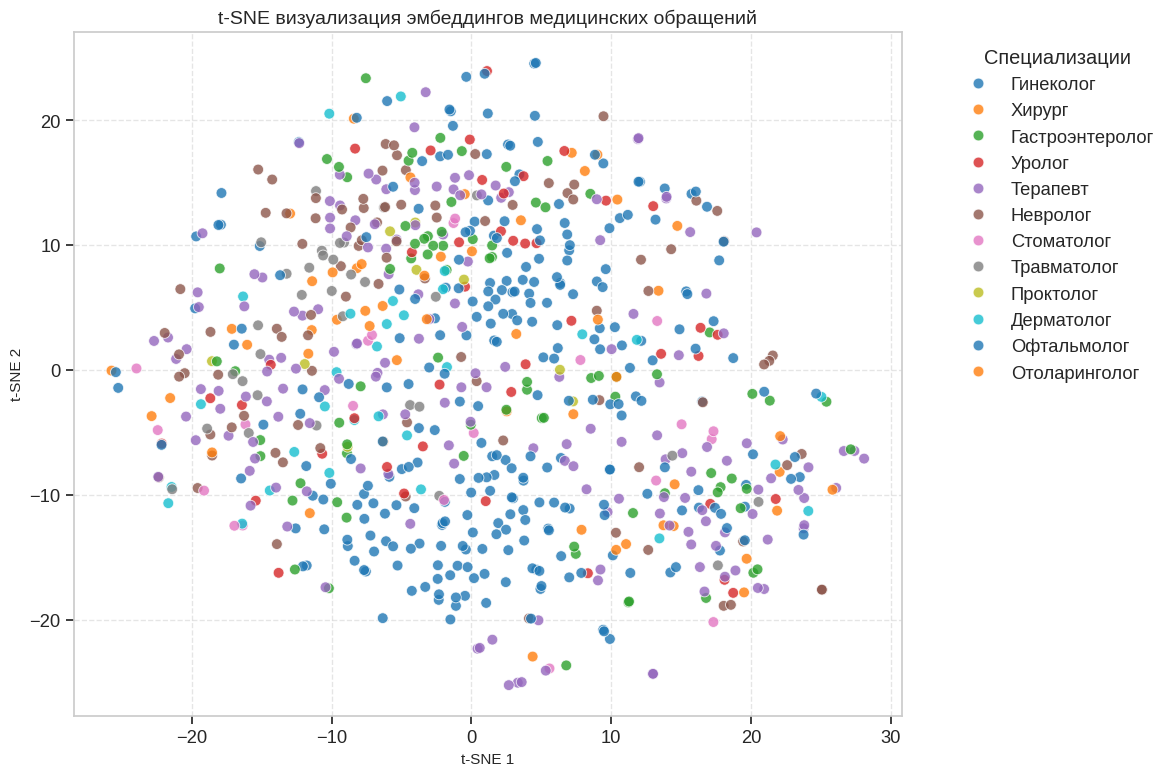

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('cointegrated/rubert-tiny2')

tsne_df = semantic_df.dropna(subset=["desc", "spec10"]).sample(
    n=min(800, len(semantic_df)),
    random_state=42
).reset_index(drop=True)

embeddings = embedder.encode(
    tsne_df["desc"].astype(str).tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init="pca",
    random_state=42
)

embeddings_2d = tsne.fit_transform(embeddings)

tsne_df["x"] = embeddings_2d[:, 0]
tsne_df["y"] = embeddings_2d[:, 1]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=tsne_df,
    x="x",
    y="y",
    hue="spec10",
    alpha=0.8,
    s=60,
    palette="tab10"
)

plt.title("t-SNE визуализация эмбеддингов медицинских обращений", fontsize=14)
plt.xlabel("t-SNE 1", fontsize=11)
plt.ylabel("t-SNE 2", fontsize=11)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Специализации"
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Ваши выводы по графику:**

*На графике видно, что классы...* с выраженной общей лексикой (такие как терапевт, хирург, уролог и невролог) сильно перемешаны между собой в центральной и левой частях, отражая сходство описываемых симптомов. В то же время категория «Гинеколог» занимает наибольшую область с высокой плотностью точек в нижней частииз-за преобладания в датасете, а узкопрофильные классы  формируют более сгруппированные локальные кластеры



## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**

Главная проблема при очистке стали сильный дисбаланс классов с преобладанием класса «Гинеколога»

Наиболее эффективный метод дедупликации: Наиболее эффективным оказался семантический метод с моделью bge-m3, так как в отличие от точного и нечеткого поиска он смог отловить полноценные парафразы и смысловые дубликаты

В zero-shot режиме модель Qwen2.5-3B-Instruct показала неплохой результат Accuracy:  0.7158
Macro F1:  0.5810


# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Анализ ошибок:**

*Модель ошиблась на примерах... Я думаю это связано с тем, что...*



## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Обоснование выбора порога:**

*Оптимальный порог T=... потому что...*



## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# Для загрузки можно использовать метод dataset.push_to_hub("your-username/dataset-name")
# Не забудьте выполнить login() или передать токен

# ССЫЛКА НА ВАШ ДАТАСЕТ: https://huggingface.co/datasets/...

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

*...*

